# Dependency imports

In [24]:
import torch

#Vajon melyik lesz?
from timm import create_model
from torchvision.models import swin_b   #<- Eddig 2 hajszállal

from Training.library import validate
import Training.library as lib
from Training.training import Config, TrainingResources, initMelanomaDetectorTrainers
import Training.metrics as m
import Training.plotting as plots

from time import sleep

# MelanomaDetector specific configuration

In [25]:
c = Config("MelanomaDetector")
#c = Config("MelanomaDetector-CoAtNet")

#Configure execution to needs
c.purge    = False

c.loadBest = False

#Itt finomhangolás megy, tehát kisebb is elég
#+ Csak a végső osztályozót tanítom, ami ugyanaz minden backbone-nál
#CoAtNetnél alapból 8e-7
#Swinnél alapból: 8e-6
c.learningRate = 1e-6   #initial learning rate (sched eta_min = lr * 0.1)

c.weightDecay  = 5e-2
#c.binaryThreshold = 0.35

c.numClasses = 1  #Melanoma valószínüsége
c.batchSize = 8
c.workers = 8
#this time its important to set epochs here
c.trainingEpochs = 40


# Initialize resources

In [26]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
oldClasses = 8

Using cuda device


In [27]:
#NOTE: Melanoma detectorok alapból Swin-ek, akkor CoAtNet ha benne van a nevében

if "CoAtNet" in c.modelName:
    model = create_model(
        "coatnet_2_rw_224",
        pretrained=False,       #I'll load weights anyway
        num_classes=oldClasses  #So the base is loadable
    )
    #The starting base is the test model already trained on skin lesions
    model.load_state_dict(
        torch.load("Models/CoAtNet-2/best_val.pth", map_location=torch.device(device))
    )
    #The classifier is binary from now
    model.reset_classifier(c.numClasses)
else: 
    model = swin_b(weights=None)
    model.head = torch.nn.Linear(model.head.in_features, oldClasses) #oldClasses so base is loadable
    #The starting base is the test model already trained on skin lesions
    model.load_state_dict(
        torch.load("Models/Swin-B/best_val.pth", map_location=torch.device(device))
    )
    model.head = torch.nn.Linear(model.head.in_features, c.numClasses)

In [28]:
#Freeze every layer exept the classifier
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

#NOTE: Resources use scheduler too
TR = TrainingResources(c, model, initMelanomaDetectorTrainers, device)
TR.load(c)


print(TR.criterion)
print(TR.optimizer)
print(TR.scheduler)
#Note: After this point only some config changes will apply


Loaded state
BCEWithLogitsLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 1e-06
    lr: 4.796044907350461e-07
    maximize: False
    weight_decay: 0.05
)


# Execute training

### Overwrite training functions due to different characteristics of the task

In [29]:
#NOTE: 
# For binary classification only loss is recorded
# In validate, CM is removed instead probs are recorded so 
# multiple tresholds can be tried out

def trainingEpoch(TR:TrainingResources):
    """
        Executes a single training epoch on the model
    """
    TR.criterion.to(device)
    TR.model.train()
    TR.model.to(device)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in TR.train_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        TR.optimizer.zero_grad()

        logits = model(images)
        probs = torch.sigmoid(logits)
        loss = TR.criterion(logits, labels)

        #updating model weights
        loss.backward()
        TR.optimizer.step()
        TR.scheduler.step()

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
    
    train_loss = running_loss / total
    return train_loss

@torch.no_grad()
def validate(TR:TrainingResources, dataLoader):
    #
    TR.model.to(device)
    TR.criterion.to(device)
    TR.model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    #confusion matrix removed due tue experimenting with different thresholds
    allLabels = []
    allProbs = []

    for images, labels in dataLoader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        logits = model(images)
        probs = torch.sigmoid(logits).squeeze(1)
        loss = TR.criterion(logits, labels)

        running_loss += loss.item() * labels.size(0)

        allLabels.extend(labels.detach().cpu())
        allProbs.extend(probs.detach().cpu())
        total += labels.size(0)

    loss = running_loss / total
    return loss, allLabels, allProbs


def trainingLoop(c:Config, tr:TrainingResources, stopAt = 0):
    if not c.training:
        print("Training turned off")
        return
    if c.loadBest:
        print("Probably best model is loaded, training would ruin it!")
        return

    #Free up memory
    torch.cuda.empty_cache()

    epochs = c.trainingEpochs
    if stopAt: epochs = stopAt

    #bestTrainLoss = None
    bestValLoss = None
    if tr.history is not None and len(tr.history) > 0:
        #bestTrainLoss = tr.history["train_loss"].min()
        bestValLoss = tr.history["val_loss"].min()

    for epoch in range(tr.epochs_done, epochs):
        print(f"Epoch {epoch+1}/{epochs} \t| ", end="")
        #Executing training and validation
        train_loss = trainingEpoch(tr)
        val_loss, _, _ = validate(tr, tr.val_loader)

        print(
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_loss:.4f}"
        )
        tr.epochs_done += 1

        #Recording statistics
        statRow = {
            "epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss
        }
        tr.recordStat(statRow)
        tr.save()

        #saving best model
        if not bestValLoss or val_loss < bestValLoss:
            bestValLoss = val_loss
            torch.save(model.state_dict(), tr.bestValPath)
        
        if epoch == epochs-1: break
        sleep(c.gpuSleep) #Let GPU cool a little


### Actually executing the training loop

In [37]:
# Override training related config if neccesary
c.training = True
c.gpuSleep = 20

trainingLoop(c, TR, stopAt=35)

Epoch 34/35 	| 

train loss: 0.3912 | val loss: 0.5561
Epoch 35/35 	| train loss: 0.3869 | val loss: 0.5563


In [38]:
minLossRow = TR.history[ TR.history["val_loss"] == TR.history["val_loss"].min() ]
print(minLossRow)
display(TR.history)

    epoch  train_loss  val_loss
33     34     0.39124  0.556113


,epoch,train_loss,val_loss
0,1,1.066567,1.034636
1,2,0.985077,0.957433
2,3,0.914590,0.892911
3,4,0.851377,0.838948
4,5,0.794890,0.792588
5,6,0.746908,0.754707
6,7,0.711317,0.722789
7,8,0.668706,0.695670
8,9,0.641625,0.673793
9,10,0.611677,0.655489


# Plots of learning process

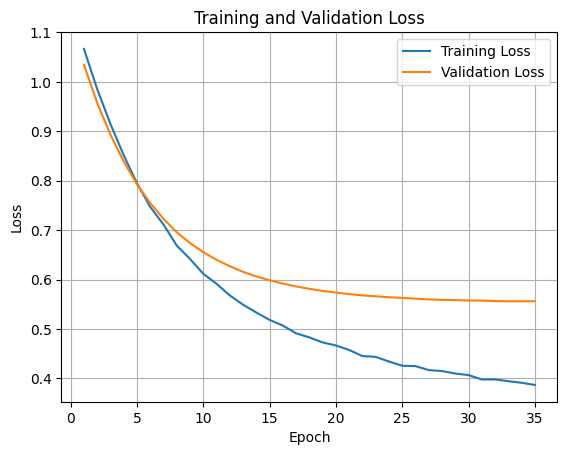

In [39]:
plots.plotBinaryTraining(TR.history, TR.plotsFolder)

# Treshold Tuning

### Evaluate on test set

In [40]:
#Reload weights with best validation
c.loadBest = True

TR.load(c)

dl = TR.test_loader

test_loss, allLabels, allProbs = validate(TR, dl)
print(f"Test loss: {test_loss}")

Loaded state
Test loss: 0.5470388923104353


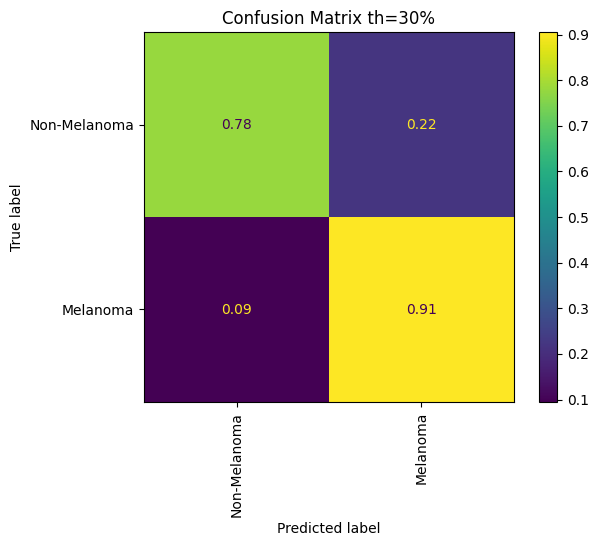

,Non-Melanoma,Melanoma
Non-Melanoma,1625,43
Melanoma,462,410


,accuracy,precision,recall,f1
Non-Melanoma,80.12,97.42,77.86,86.55
Melanoma,80.12,47.02,90.51,61.89


In [41]:
#Experiment with different tresholds
#THRESHOLDS = [ 0.50, 0.40, 0.30, 0.25, 0.20 ]
#THRESHOLDS = [ p/100 for p in range(40, 29, -2)]
THRESHOLDS = [ 0.30 ]

classNames = dl.dataset.classes

bestThreshold = 0.0

for th in THRESHOLDS:
    CM = m.initCM(classNames)
    for prob, label in zip(allProbs, allLabels):
        pred = prob >= th
        CM.loc[classNames[int(pred)], classNames[int(label)]] += 1 #konvenciónak megfelelő
    
    metrics = plots.deriveMetrics(CM, TR.plotsFolder)
    plots.plotConfusionMatrix(CM, TR.plotsFolder + f"/{th}_", th)
    display(CM)
    display(metrics)